In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OneHotEncoder

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('Dataset/paysim dataset.csv')
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [3]:
print(df.isnull().sum())
print(df.duplicated().sum())

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64
0


In [4]:
print("Number of rows before removing duplicates:", len(df))
df.drop_duplicates(inplace=True)
print("Number of rows after removing duplicates:", len(df))

Number of rows before removing duplicates: 6362620
Number of rows after removing duplicates: 6362620


In [5]:
df = df.drop(['nameOrig', 'nameDest', 'isFlaggedFraud'], axis=1)
df.describe(include='all')

,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud
count,6.362620e+06,6362620,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
unique,NaN,5,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,CASH_OUT,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,2237500,NaN,NaN,NaN,NaN,NaN,NaN
mean,2.433972e+02,NaN,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03
std,1.423320e+02,NaN,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02
min,1.000000e+00,NaN,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,NaN,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,NaN,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00
75%,3.350000e+02,NaN,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00


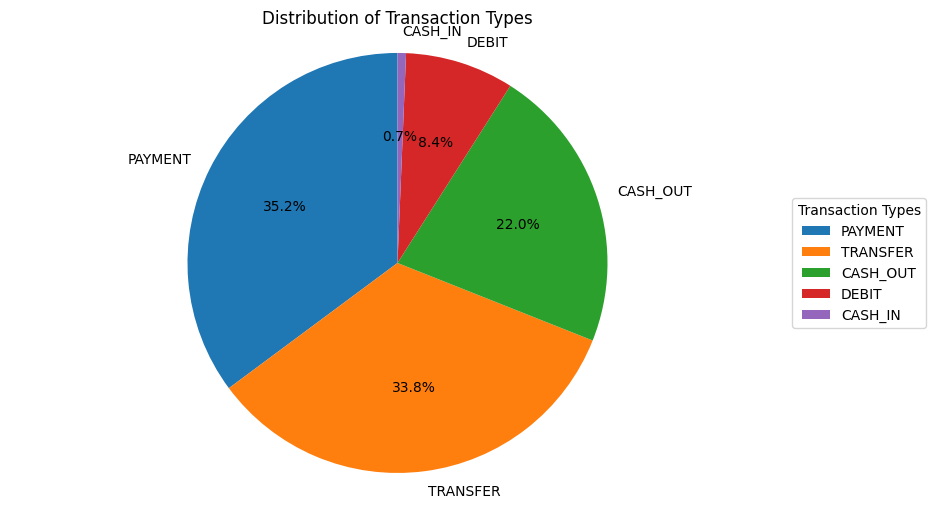

In [6]:
labels = df['type'].unique().tolist()

plt.figure(figsize=(10, 6))
wedges, texts, autotexts = plt.pie(df['type'].value_counts(), labels=labels, autopct='%1.1f%%', startangle=90)
plt.title('Distribution of Transaction Types')
plt.axis('equal')
plt.legend(wedges, labels, title='Transaction Types', loc='center left', bbox_to_anchor=(1, 0, 0.5, 1))
plt.show()

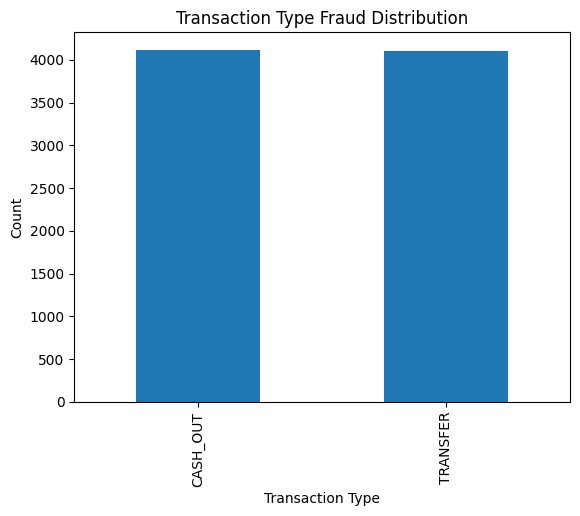

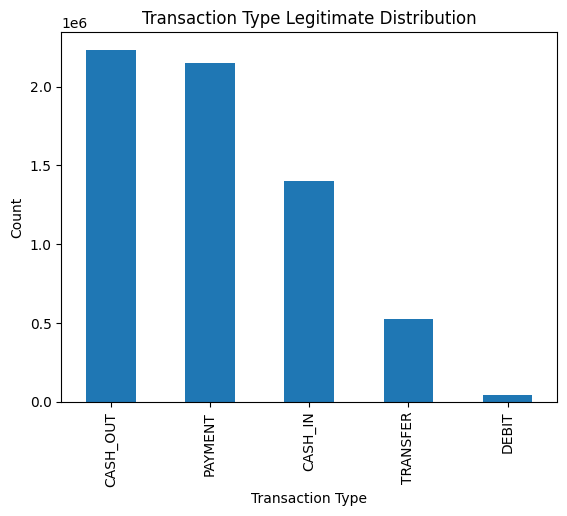

In [7]:
df[df['isFraud']==1]['type'].value_counts().plot(kind='bar')
plt.title('Transaction Type Fraud Distribution')
plt.xlabel('Transaction Type')
plt.ylabel('Count')
plt.show()

df[df['isFraud']==0]['type'].value_counts().plot(kind='bar')
plt.title('Transaction Type Legitimate Distribution')
plt.xlabel('Transaction Type')
plt.ylabel('Count')
plt.show()

In [8]:
df['OrgbalanceDiff'] = df['newbalanceOrig'] - df['oldbalanceOrg']
df['DestbalanceDiff'] = df['newbalanceDest'] - df['oldbalanceDest']
df[df['DestbalanceDiff']!=0][['amount','OrgbalanceDiff', 'DestbalanceDiff', 'isFraud']].head(10)

,amount,OrgbalanceDiff,DestbalanceDiff,isFraud
3,181.00,-181.00,-21182.00,1
9,5337.77,-5337.77,-1549.21,0
10,9644.94,-4465.00,147137.12,0
15,229133.94,-15325.00,46430.44,0
19,215310.30,-705.00,-22425.00,0
21,9302.79,-9302.79,-12935.30,0
22,1065.41,-1065.41,-10330.00,0
24,311685.89,-10835.00,2712905.89,0
41,5758.59,-5758.59,-192701.78,0
42,110414.71,-26845.41,-286384.84,0


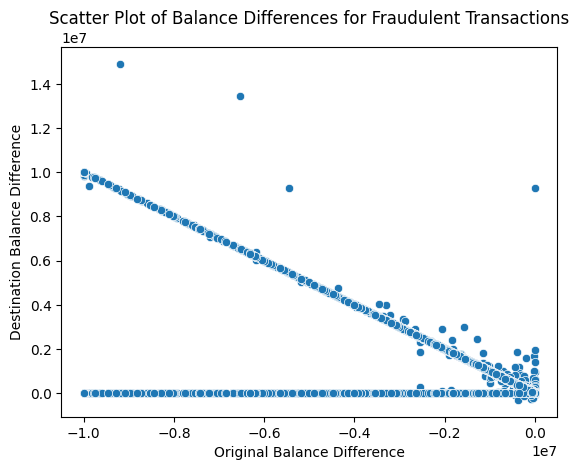

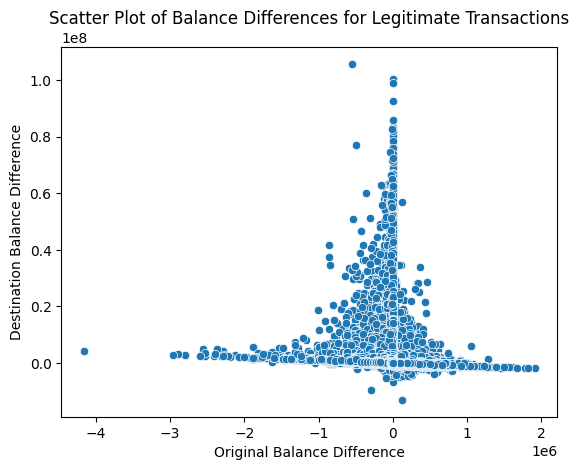

In [9]:
sns.scatterplot(data=df[df['isFraud']==1], x='OrgbalanceDiff', y='DestbalanceDiff')
plt.title('Scatter Plot of Balance Differences for Fraudulent Transactions')
plt.xlabel('Original Balance Difference')
plt.ylabel('Destination Balance Difference')
plt.show()

sns.scatterplot(data=df[df['isFraud']==0], x='OrgbalanceDiff', y='DestbalanceDiff')
plt.title('Scatter Plot of Balance Differences for Legitimate Transactions')
plt.xlabel('Original Balance Difference')
plt.ylabel('Destination Balance Difference')
plt.show()

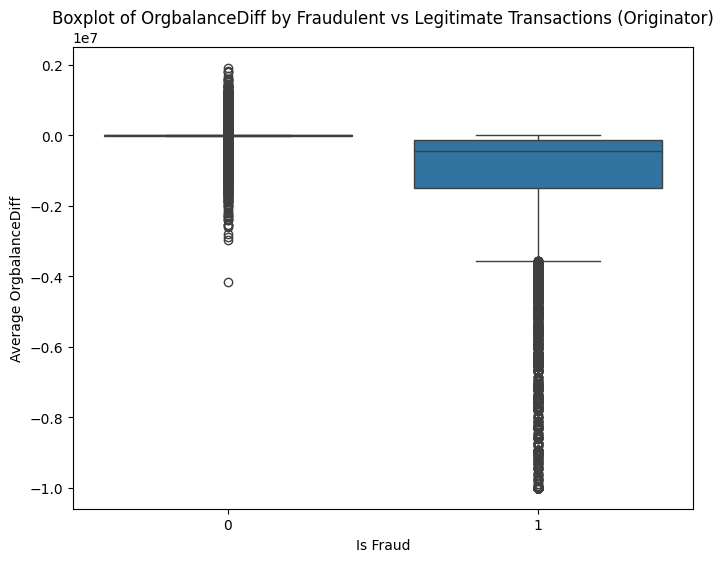

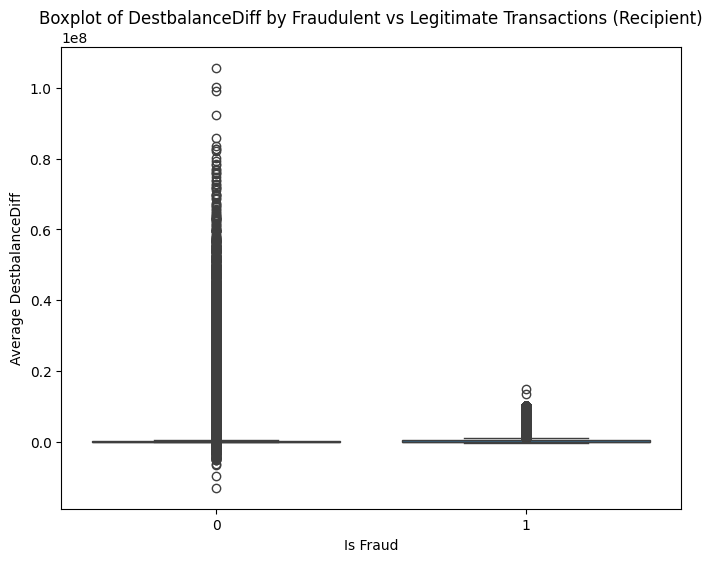

In [10]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='isFraud', y='OrgbalanceDiff', data=df)
plt.title('Boxplot of OrgbalanceDiff by Fraudulent vs Legitimate Transactions (Originator)')
plt.xlabel('Is Fraud')
plt.ylabel('Average OrgbalanceDiff')
plt.show()

plt.figure(figsize=(8, 6))
sns.boxplot(x='isFraud', y='DestbalanceDiff', data=df)
plt.title('Boxplot of DestbalanceDiff by Fraudulent vs Legitimate Transactions (Recipient)')
plt.xlabel('Is Fraud')
plt.ylabel('Average DestbalanceDiff')
plt.show()

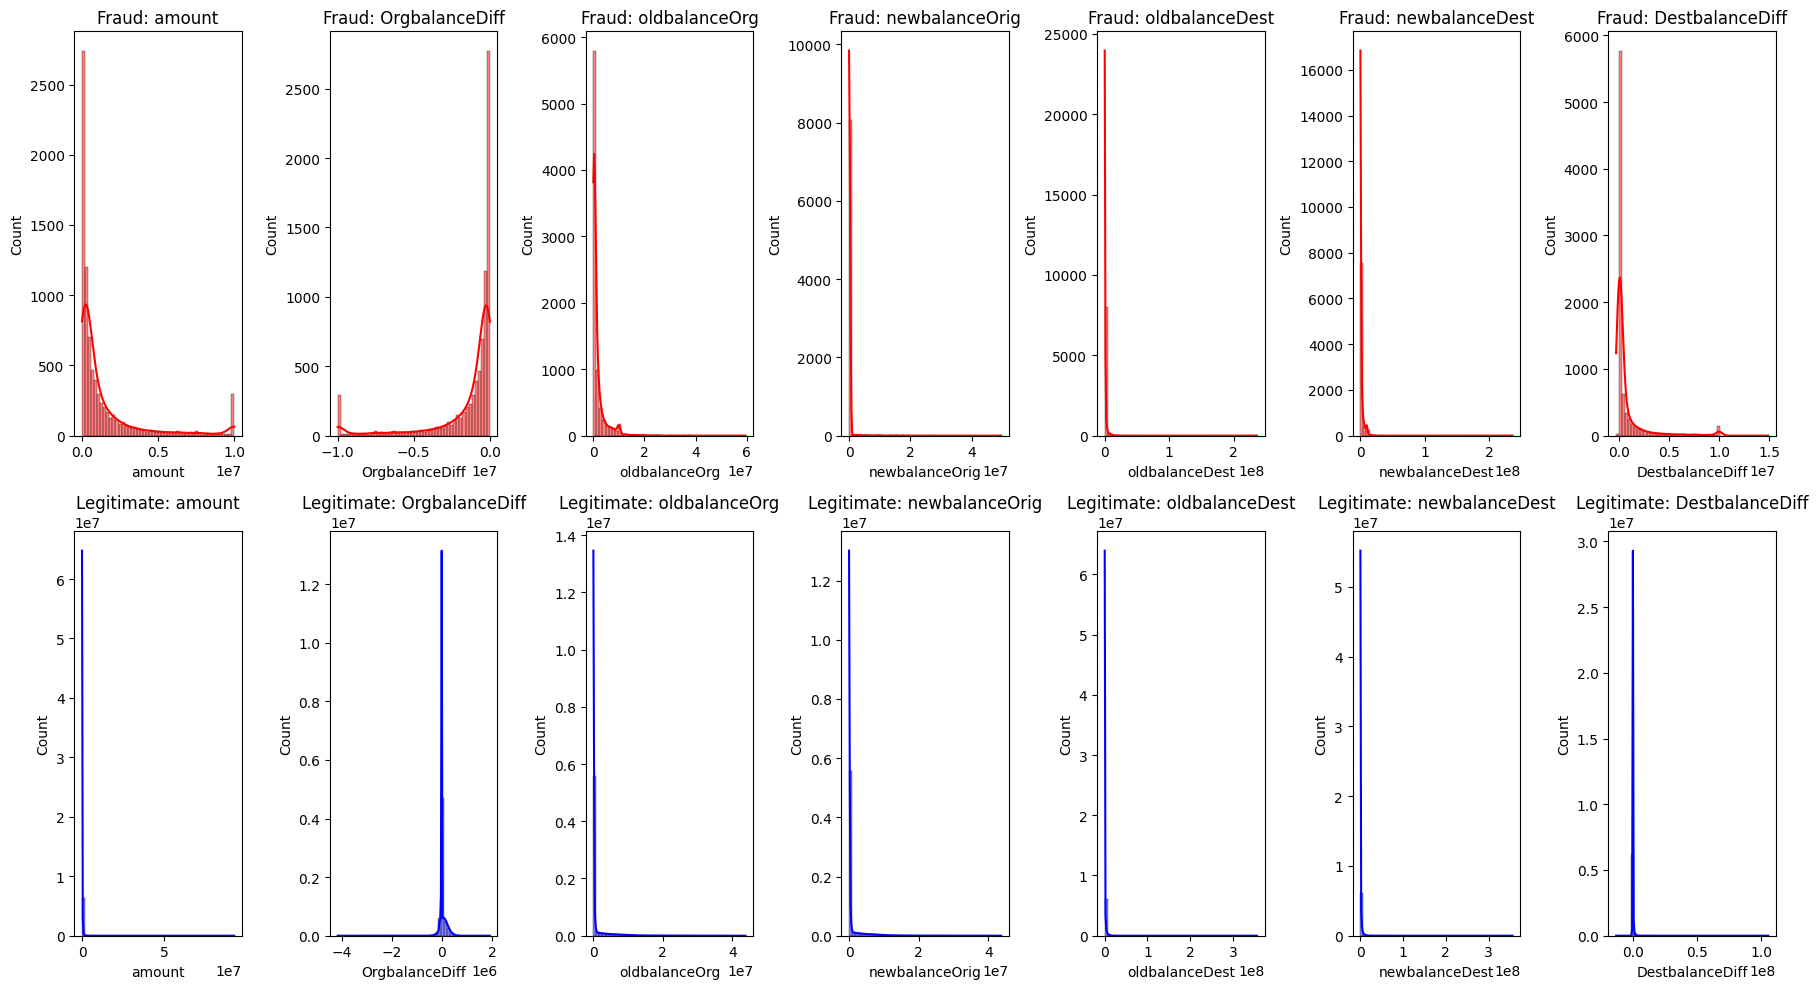

In [11]:
df_tempF = df[df['isFraud'] == 1][['amount', 'OrgbalanceDiff', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'DestbalanceDiff']]
df_tempL = df[df['isFraud'] == 0][['amount', 'OrgbalanceDiff', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'DestbalanceDiff']]
cols = ['amount', 'OrgbalanceDiff', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'DestbalanceDiff']

fig, axes = plt.subplots(figsize=(18, 10), nrows=2, ncols=7)
for i, col in enumerate(cols):
    sns.histplot(df_tempF[col], bins=50, kde=True, ax=axes[0, i], color='red')
    axes[0, i].set_title(f'Fraud: {col}')
    axes[0, i].set_xlabel(col)

for i, col in enumerate(cols):
    sns.histplot(df_tempL[col], bins=50, kde=True, ax=axes[1, i], color='blue')
    axes[1, i].set_title(f'Legitimate: {col}')
    axes[1, i].set_xlabel(col)

plt.tight_layout()
plt.show()

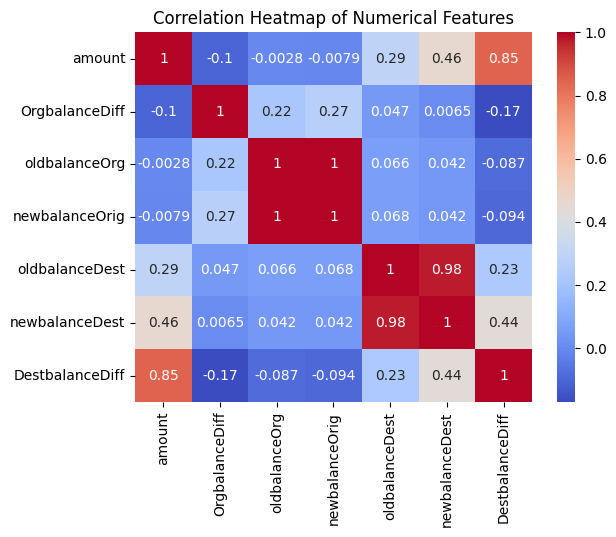

In [12]:
df_temp = df[['amount', 'OrgbalanceDiff', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'DestbalanceDiff']]
sns.heatmap(df_temp.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

In [13]:
df['hour_of_day'] = df['step'] % 24
df['day_of_week'] = (df['step'] // 24) % 7

df = df.drop('step', axis=1)
df.head()

,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,OrgbalanceDiff,DestbalanceDiff,hour_of_day,day_of_week
0,PAYMENT,9839.64,170136.0,160296.36,0.0,0.0,0,-9839.64,0.0,1,0
1,PAYMENT,1864.28,21249.0,19384.72,0.0,0.0,0,-1864.28,0.0,1,0
2,TRANSFER,181.00,181.0,0.00,0.0,0.0,1,-181.00,0.0,1,0
3,CASH_OUT,181.00,181.0,0.00,21182.0,0.0,1,-181.00,-21182.0,1,0
4,PAYMENT,11668.14,41554.0,29885.86,0.0,0.0,0,-11668.14,0.0,1,0


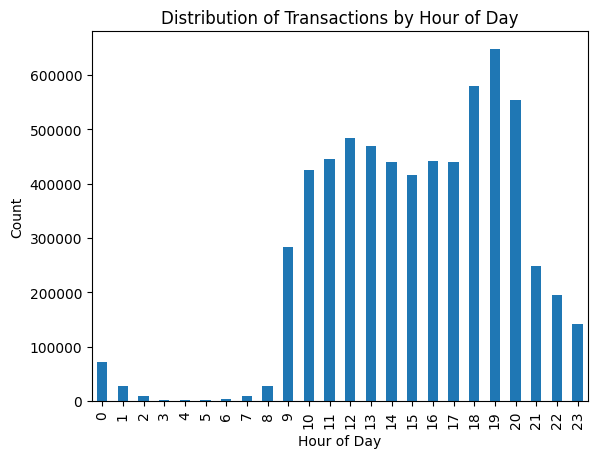

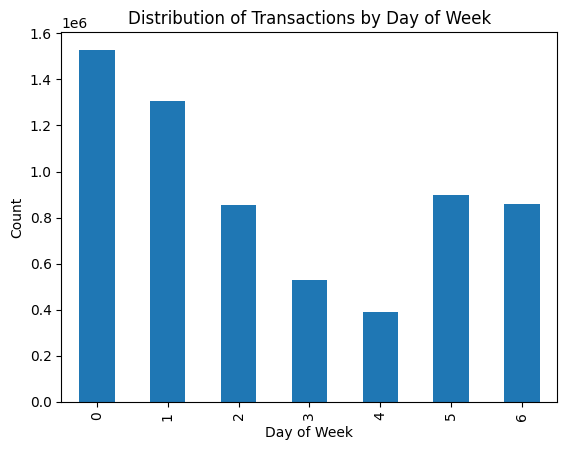

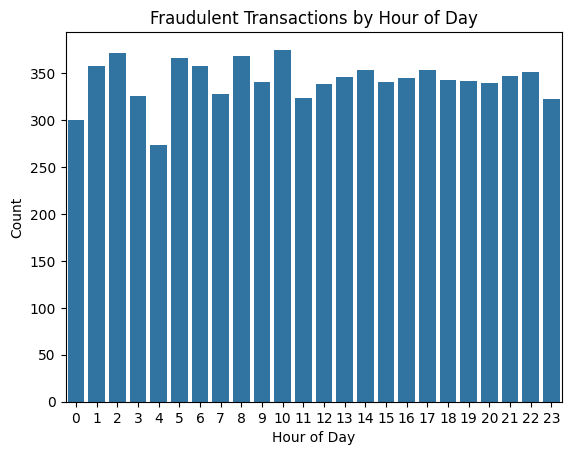

In [14]:
df['hour_of_day'].value_counts().sort_index().plot(kind='bar')
plt.title('Distribution of Transactions by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Count')
plt.show()

df['day_of_week'].value_counts().sort_index().plot(kind='bar')
plt.title('Distribution of Transactions by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Count')
plt.show()

sns.countplot(data=df[df['isFraud']==1], x='hour_of_day')
plt.title('Fraudulent Transactions by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Count')
plt.show()

In [15]:
print("Number of rows before filtering by transaction type:", len(df))
df = df[df['type'].isin(['TRANSFER', 'CASH_OUT'])]
print("Number of rows after filtering by transaction type:", len(df))

Number of rows before filtering by transaction type: 6362620
Number of rows after filtering by transaction type: 2770409


**one-hot encoding**

In [16]:
oneHotEncoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
ohe_features = oneHotEncoder.fit_transform(df[['type']])
ohe_df = pd.DataFrame(ohe_features, columns=oneHotEncoder.get_feature_names_out(['type']))
df = pd.concat([df.reset_index(drop=True), ohe_df], axis=1)
df = df.drop(['type'], axis=1)
df.head()

,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,OrgbalanceDiff,DestbalanceDiff,hour_of_day,day_of_week,type_CASH_OUT,type_TRANSFER
0,181.00,181.0,0.0,0.0,0.00,1,-181.0,0.00,1,0,0.0,1.0
1,181.00,181.0,0.0,21182.0,0.00,1,-181.0,-21182.00,1,0,1.0,0.0
2,229133.94,15325.0,0.0,5083.0,51513.44,0,-15325.0,46430.44,1,0,1.0,0.0
3,215310.30,705.0,0.0,22425.0,0.00,0,-705.0,-22425.00,1,0,0.0,1.0
4,311685.89,10835.0,0.0,6267.0,2719172.89,0,-10835.0,2712905.89,1,0,0.0,1.0


In [17]:
df.to_csv('Dataset/paysim_dataset_processed.csv', index=False)
print("Preprocessed dataset saved to 'Dataset/paysim_dataset_processed.csv'")

Preprocessed dataset saved to 'Dataset/paysim_dataset_processed.csv'
